# Classification

It's a problem of predicting is the input is something or belongs to a class or not.

There are three types:
- Binary Classification: Predict if the input belongs to class A or B.
- Multiclass Classification: Predict if the input belongs to one of n possible classes.
- Multi labeled classification: Predict all the possible classes/labels that the input belongs to. e.g.: An article can have various labels inlcluding CS, AI, Mathematics, Learning, etc.

## 1. Make Classification Data

In [1]:
from sklearn.datasets import make_circles

n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [2]:
len(X), len(y)

(1000, 1000)

In [3]:
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [4]:
# make DataFrame of Circle Data
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})
circles

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


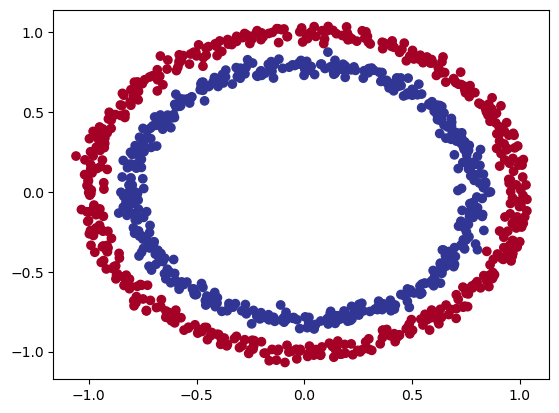

In [5]:
# Visualize
import matplotlib.pyplot as plt

plt.scatter(
    x=X[:, 0],
    y=X[:, 1],
    c=y,
    cmap=plt.cm.RdYlBu
)

### 1.1 Check Input & Output Shapes

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
# View first example of features & labels
X_sample = X[0]
y_sample = y[0]

X_sample, y_sample, X_sample.shape, y_sample.shape

(array([0.75424625, 0.23148074]), np.int64(1), (2,), ())

### 1.2 Turn into Tensors & Creating train-test split

In [8]:
import torch

In [9]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [10]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
X_train[:5], y_train[:5]

(tensor([[-0.7716,  0.2325],
         [-0.7767,  0.1769],
         [-0.1272,  1.0223],
         [-0.9900, -0.3340],
         [-0.1989, -0.9379]]),
 tensor([1., 1., 0., 0., 0.]))

In [13]:
len(X_train), len(X_test)

(800, 200)

## 2. Building Model

In [14]:
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [15]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=5) # Takes 2 inputs & upscales it to 5 features
        self.layer2 = nn.Linear(in_features=5, out_features=1) # takes 5 features from previous layer & outputs a single feature

    def forward(self, x):
        return self.layer2(self.layer1(x)) # x -> Layer1 -> Layer2

In [16]:
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.7018,  0.1904],
                      [-0.4770,  0.3467],
                      [-0.6128, -0.4583],
                      [-0.4562, -0.1001],
                      [ 0.4477,  0.0540]], device='cuda:0')),
             ('layer1.bias',
              tensor([ 0.2728, -0.5933,  0.0912,  0.3494, -0.0631], device='cuda:0')),
             ('layer2.weight',
              tensor([[-0.2212, -0.3004,  0.0036,  0.2232, -0.1864]], device='cuda:0')),
             ('layer2.bias', tensor([0.0306], device='cuda:0'))])

In [18]:
next(model_0.parameters()).device

device(type='cuda', index=0)

### We can replicate the model in a simpler way using `nn.Sequential()`

In [19]:
model_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_1

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [20]:
model_1.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.0253, -0.6082],
                      [-0.0130, -0.3171],
                      [ 0.5587,  0.0734],
                      [ 0.1386, -0.0297],
                      [-0.1817,  0.4636]], device='cuda:0')),
             ('0.bias',
              tensor([-0.2676, -0.0133,  0.4172, -0.5420, -0.1784], device='cuda:0')),
             ('1.weight',
              tensor([[-0.3965, -0.2400,  0.1159, -0.1728, -0.4050]], device='cuda:0')),
             ('1.bias', tensor([-0.0241], device='cuda:0'))])

In [21]:
next(model_1.parameters()).device

device(type='cuda', index=0)

In [22]:
# make prediction
with torch.inference_mode():
    untrained_preds = model_1(X_test.to(device))

untrained_preds.shape, len(untrained_preds), untrained_preds[:10], y_test[:10]

(torch.Size([200, 1]),
 200,
 tensor([[0.1360],
         [0.4432],
         [0.4284],
         [0.2952],
         [0.4330],
         [0.3071],
         [0.3545],
         [0.4109],
         [0.3052],
         [0.3402]], device='cuda:0'),
 tensor([0., 1., 1., 1., 1., 1., 0., 1., 0., 0.]))

### 2.1 Setup Loss Function & Optimizer

which Loss Function & Optimizer to use entirely depends upon the type of problem

Common Loss:
- Regression: MAE or MSE
- Classification: Cross Entropy or Binary Cross Entropy

Common Optimizers:
- SGD
- Adam

In [23]:
# loss_fn = nn.BCELoss() # Requires inputs to have gone through Sigmoid Activation function
loss_fn = nn.BCEWithLogitsLoss() # Sigmoid activation function is built-in | more numerically stable

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [24]:
loss_fn, optimizer

(BCEWithLogitsLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [25]:
# Aclculate accuracy. What percentage of predictions does our model gets correct?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

## 3. Train the Model

Steps to Train the Model:
1. Set model to train mode
2. make predictions / Feed-Forward
3. calculate loss
4. zero grad
5. backpropagation
6. gradient descent

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**.

We can convert the **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g.: **Sigmoid** for binary classification and **Softmax** for multi-class classification)

Then we can convert our model's prediction probabilities to **prediction label** by either rounding them or taking the `argmax()`

In [26]:
# View first 5 outputs of the forward pass
model_1.eval()
with torch.inference_mode():
    y_logits = model_1(X_test.to(device))[:5]
y_logits, y_test[:5]

(tensor([[0.1360],
         [0.4432],
         [0.4284],
         [0.2952],
         [0.4330]], device='cuda:0'),
 tensor([0., 1., 1., 1., 1.]))

In [27]:
# Use Sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5339],
        [0.6090],
        [0.6055],
        [0.5733],
        [0.6066]], device='cuda:0')

For the prediction probability values, we need to perform a range-style rounding on them:
- `y_pred_probs` >= 0.5, `y=1` (class 1)
- `y_pred_probs` < 0.5, `y=0` (class 0)

In [28]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)
y_preds

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], device='cuda:0')

In [29]:
# Full implementation in one
y_pred_labels = torch.round(torch.sigmoid(model_1(X_test.to(device)[:5])))
y_pred_labels

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]], device='cuda:0', grad_fn=<RoundBackward0>)

In [30]:
# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0')

### 3.2 Building a Training & Test Loop

In [31]:
epochs = 100

steps = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    logits = model_1(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(logits)) # Logit -> Pred Probabilities -> Pred Labels
    loss = loss_fn(logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    if epoch % 10 == 0:
        model_1.eval()
        with torch.inference_mode():
            logits = model_1(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(logits))
            test_loss = loss_fn(logits, y_test)
            test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)
        steps.append(epoch)
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(acc)
        test_accs.append(test_acc)

        print(f"Epoch: {epoch} \n\tLoss:\n\t\t Train: {loss} | Test: {test_loss}\n\tAccuracy:\n\t\tTrain: {acc} | Test: {test_acc}")

Epoch: 0 
	Loss:
		 Train: 0.7062644958496094 | Test: 0.7034725546836853
	Accuracy:
		Train: 49.875 | Test: 50.5
Epoch: 10 
	Loss:
		 Train: 0.6984111070632935 | Test: 0.6972105503082275
	Accuracy:
		Train: 49.875 | Test: 50.5
Epoch: 20 
	Loss:
		 Train: 0.6954732537269592 | Test: 0.6950536966323853
	Accuracy:
		Train: 57.75 | Test: 58.5
Epoch: 30 
	Loss:
		 Train: 0.6943051218986511 | Test: 0.694317102432251
	Accuracy:
		Train: 52.87500000000001 | Test: 51.5
Epoch: 40 
	Loss:
		 Train: 0.6938051581382751 | Test: 0.6940786838531494
	Accuracy:
		Train: 52.0 | Test: 50.0
Epoch: 50 
	Loss:
		 Train: 0.6935679316520691 | Test: 0.6940122246742249
	Accuracy:
		Train: 50.875 | Test: 48.5
Epoch: 60 
	Loss:
		 Train: 0.6934395432472229 | Test: 0.6940019726753235
	Accuracy:
		Train: 50.74999999999999 | Test: 48.0
Epoch: 70 
	Loss:
		 Train: 0.6933594942092896 | Test: 0.6940076947212219
	Accuracy:
		Train: 50.125 | Test: 49.0
Epoch: 80 
	Loss:
		 Train: 0.693303644657135 | Test: 0.694016396999359

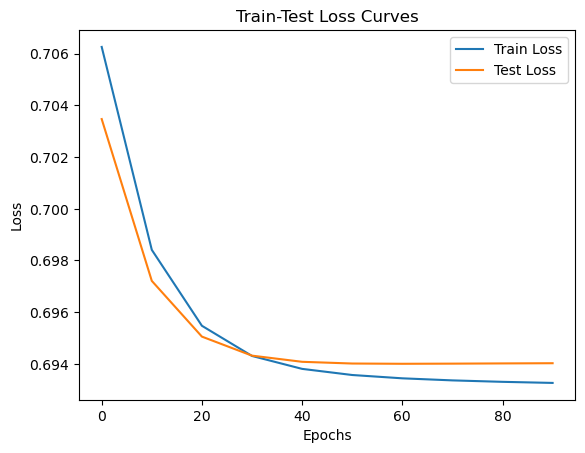

In [32]:
import numpy as np
plt.plot(steps, train_losses, label="Train Loss")
plt.plot(steps, test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train-Test Loss Curves")
plt.legend()
plt.show();

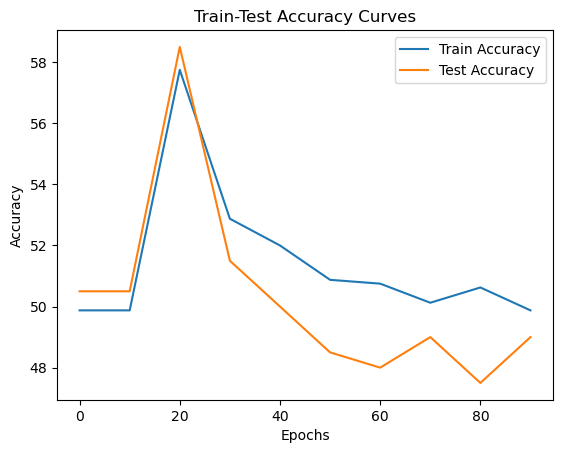

In [33]:
plt.plot(steps, train_accs, label="Train Accuracy")
plt.plot(steps, test_accs, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train-Test Accuracy Curves")
plt.legend()
plt.show();

## 4. Make predictions and evaluate the model

Form the metrics and visualization the model isn't learning much.

So let's inspect with predictions & Visualization 

We'll use `plot_decision_boundary`

In [34]:
import requests
from pathlib import Path

FILE_NAME = "helper_functions.py"
# Download the helper fucntion
if not Path(FILE_NAME).is_file():
    req = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open(FILE_NAME, "wb") as f:
        f.write(req.content)

In [35]:
from helper_functions import plot_predictions, plot_decision_boundary

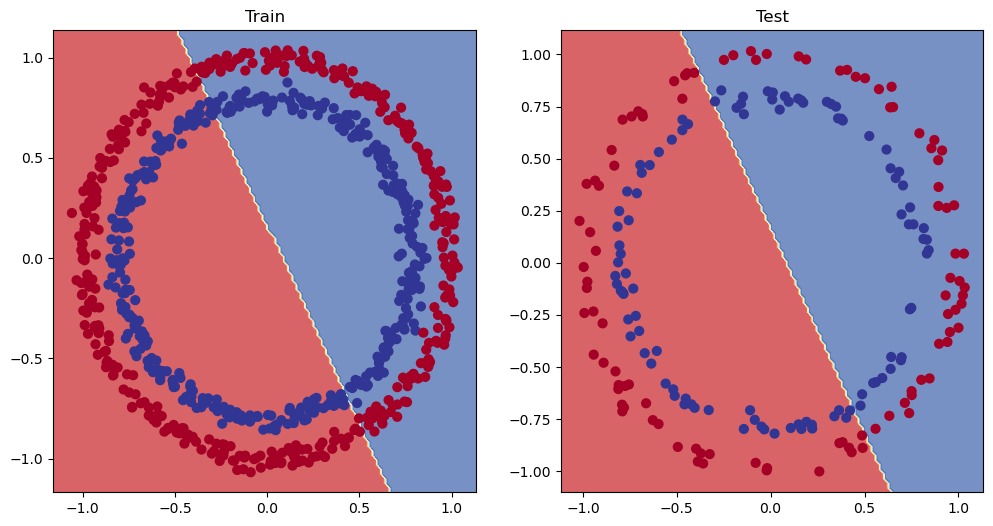

In [36]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

## 5. Improving the model

- Add more layers: Gives the model more chances to learn about patterns in the data.
- Add more hidden units/neurons: we can go from 5 to 10 neurons allowing it to learn more.
- Fit for longer
- Changing the activation functions
- Change the Learning rate
- Change the loss function

These all options are from a model's perspective because they deal directly with the model, rather than the data.

All these changes are the values that we can manually change/adjust, they are referred to as **Hyperparameters** 

Let's try to improve the model by:
- Adding more hidden units: 5 -> 10
- Increasing the number of layers: 2 -> 3
- Increasing the number of epochs from 100 -> 1000

In [37]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

In [38]:
model_2 = CircleModelV1().to(device)
model_2

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [39]:
model_2.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.6976,  0.5411],
                      [-0.4409, -0.3836],
                      [-0.3240, -0.1559],
                      [ 0.0207, -0.0171],
                      [ 0.6201,  0.5360],
                      [-0.4068, -0.2537],
                      [-0.5118, -0.4358],
                      [ 0.2892,  0.3936],
                      [-0.1906, -0.0261],
                      [ 0.4083,  0.1113]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.4068,  0.0949, -0.6239,  0.4658,  0.1755,  0.1725, -0.6084,  0.5153,
                      -0.1935, -0.1736], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.1344,  0.1868,  0.2010, -0.0973, -0.1377,  0.3054,  0.1886,  0.0286,
                       -0.2337, -0.2823],
                      [-0.1003, -0.3004,  0.1443, -0.2408,  0.0968, -0.0849, -0.1386,  0.1531,
                        0.2477, -0.3122],
                      [-0.1527,  0.030

In [40]:
next(model_2.parameters()).device

device(type='cuda', index=0)

In [41]:
# loss_fn = nn.BCELoss() # Requires inputs to have gone through Sigmoid Activation function
loss_fn = nn.BCEWithLogitsLoss() # Sigmoid activation function is built-in | more numerically stable

optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [42]:
epochs = 2000

steps = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    logits = model_2(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(logits)) # Logit -> Pred Probabilities -> Pred Labels
    loss = loss_fn(logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    if epoch % 100 == 0:
        model_1.eval()
        with torch.inference_mode():
            logits = model_2(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(logits))
            test_loss = loss_fn(logits, y_test)
            test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)
        steps.append(epoch)
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(acc)
        test_accs.append(test_acc)

        print(f"Epoch: {epoch} \n\tLoss:\n\t\t Train: {loss} | Test: {test_loss}\n\tAccuracy:\n\t\tTrain: {acc} | Test: {test_acc}")

Epoch: 0 
	Loss:
		 Train: 0.702149510383606 | Test: 0.7024300694465637
	Accuracy:
		Train: 49.875 | Test: 50.5
Epoch: 100 
	Loss:
		 Train: 0.693105936050415 | Test: 0.694571316242218
	Accuracy:
		Train: 50.125 | Test: 47.0
Epoch: 200 
	Loss:
		 Train: 0.6930800676345825 | Test: 0.6942959427833557
	Accuracy:
		Train: 50.0 | Test: 47.0
Epoch: 300 
	Loss:
		 Train: 0.6930709481239319 | Test: 0.6941523551940918
	Accuracy:
		Train: 50.24999999999999 | Test: 46.5
Epoch: 400 
	Loss:
		 Train: 0.6930673718452454 | Test: 0.6940691471099854
	Accuracy:
		Train: 50.375 | Test: 46.5
Epoch: 500 
	Loss:
		 Train: 0.6930659413337708 | Test: 0.6940186023712158
	Accuracy:
		Train: 49.875 | Test: 46.0
Epoch: 600 
	Loss:
		 Train: 0.6930654048919678 | Test: 0.693987250328064
	Accuracy:
		Train: 50.125 | Test: 46.5
Epoch: 700 
	Loss:
		 Train: 0.6930651664733887 | Test: 0.6939675807952881
	Accuracy:
		Train: 50.125 | Test: 46.5
Epoch: 800 
	Loss:
		 Train: 0.6930651664733887 | Test: 0.6939552426338196
	A

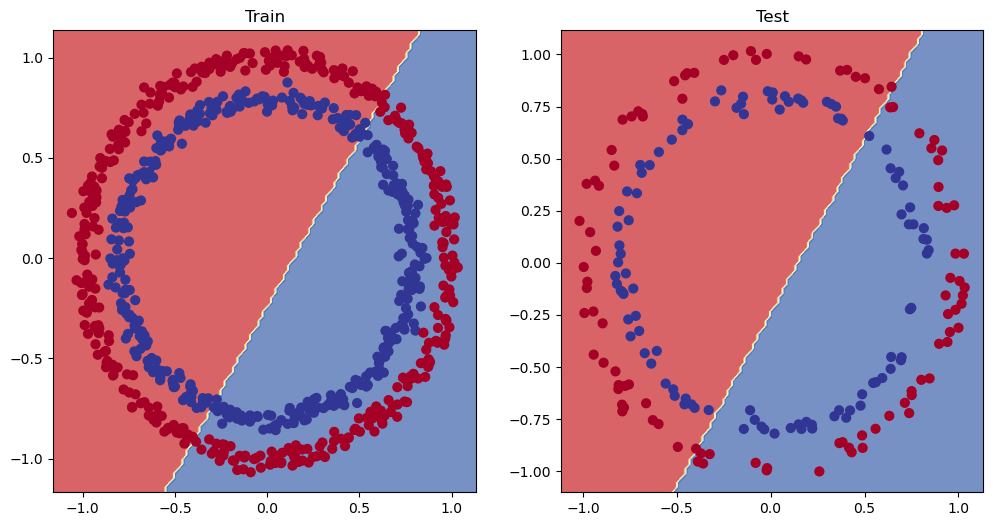

In [43]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)

### 5.1 Let's verify the models capabilities

Even after all the changes the model is basically performing the same so, let's try to verify its capabilities with some simple straight line data

In [44]:
known_weights = 0.7
known_bias = 0.3

X = torch.arange(0, 1, 0.01).unsqueeze(dim=1)
y = X * known_weights + known_bias

X[:5], y[:5], len(X)

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]),
 100)

In [45]:
split_size = int(len(X) * 0.8)
X_tr, X_tst, y_tr, y_tst = X[:split_size], X[split_size:], y[:split_size], y[split_size:]
X_tr[:2], y_tr[:2], len(X_tr), X_tst[:2], y_tst[:2], len(X_tst)

(tensor([[0.0000],
         [0.0100]]),
 tensor([[0.3000],
         [0.3070]]),
 80,
 tensor([[0.8000],
         [0.8100]]),
 tensor([[0.8600],
         [0.8670]]),
 20)

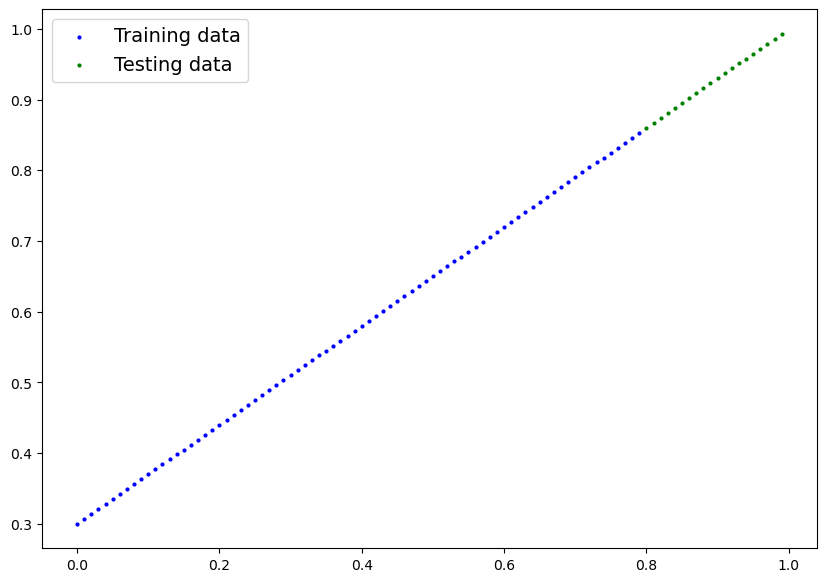

In [46]:
plot_predictions(X_tr, y_tr, X_tst, y_tst)

In [47]:
model_s = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1),
).to(device)
model_s

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [48]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_s.parameters(), lr=0.1)

In [49]:
epochs = 1000

X_tr = X_tr.to(device)
X_tst = X_tst.to(device)
y_tr = y_tr.to(device)
y_tst = y_tst.to(device)

for epoch in range(epochs):
    model_s.train()

    y_preds = model_s(X_tr)
    loss = loss_fn(y_preds, y_tr)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        # Testing
        model_s.eval()
        with torch.inference_mode():
            y_preds = model_s(X_tst)
            loss_tst = loss_fn(y_preds, y_tst)
        print(f"Epoch: {epoch} | Train Loss: {loss.item()} | Test Loss: {loss_tst.item()}")

Epoch: 0 | Train Loss: 1.2375937700271606 | Test Loss: 1.232367753982544
Epoch: 100 | Train Loss: 0.12078080326318741 | Test Loss: 0.04940979927778244
Epoch: 200 | Train Loss: 0.0822097659111023 | Test Loss: 0.031201614066958427
Epoch: 300 | Train Loss: 0.05037270858883858 | Test Loss: 0.005480069201439619
Epoch: 400 | Train Loss: 0.07990431785583496 | Test Loss: 0.02589668147265911
Epoch: 500 | Train Loss: 0.06172364950180054 | Test Loss: 0.011314156465232372
Epoch: 600 | Train Loss: 0.06663132458925247 | Test Loss: 0.023250848054885864
Epoch: 700 | Train Loss: 0.05422372370958328 | Test Loss: 0.006856956984847784
Epoch: 800 | Train Loss: 0.0703844353556633 | Test Loss: 0.019298935309052467
Epoch: 900 | Train Loss: 0.04922594502568245 | Test Loss: 0.010245147161185741


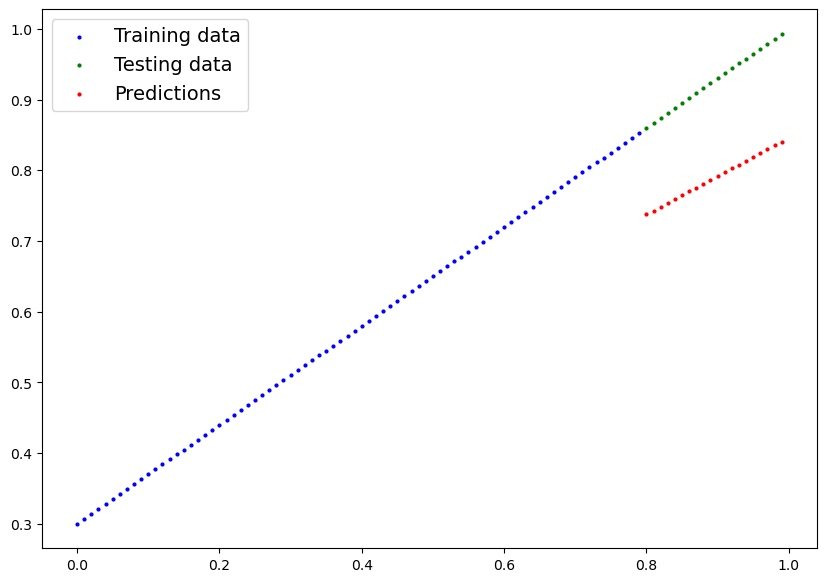

In [50]:
model_s.eval()
with torch.inference_mode():
    y_pred = model_s(X_tst)
plot_predictions(X_tr.to("cpu"), y_tr.to("cpu"), X_tst.to("cpu"), y_tst.to("cpu"), y_pred.to("cpu"))

## 6. The missing piece: Non-Linearity

"What patterns you could draw if you were given an infinite amount of a straight & non-straight lines?"

In ML it's actually just a finite amount (based on parameters)

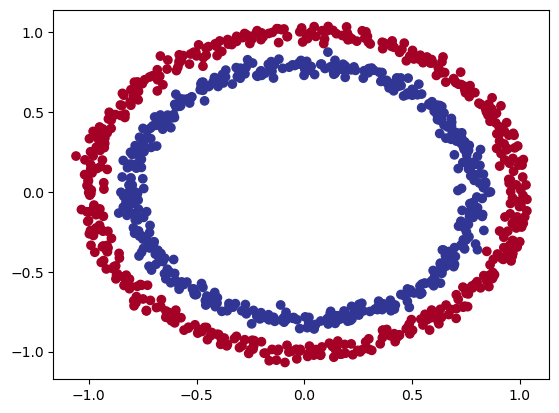

In [51]:
### 6.1 Recreating non-linear data i.e., circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [52]:
# Convert data to tensors & train test split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(y_train),len(X_test),len(y_test)

(800, 800, 200, 200)

### 6.2 Building the model with non-linearity

- Linear: Straight Lines
- Non-Linear: Non-Straight Lines

In [53]:
def test_activations(x):
    print(f"{x=} | {torch.sigmoid(x)=} | {torch.tanh(x)=} | {torch.relu(x)=}")

torch.manual_seed(189)
x = torch.randn(1)
test_activations(x)

y = torch.tensor([0.5])
test_activations(y)

z = torch.tensor([7])
test_activations(z)

z = torch.tensor([7000])
test_activations(z)

x=tensor([-0.6043]) | torch.sigmoid(x)=tensor([0.3534]) | torch.tanh(x)=tensor([-0.5401]) | torch.relu(x)=tensor([0.])
x=tensor([0.5000]) | torch.sigmoid(x)=tensor([0.6225]) | torch.tanh(x)=tensor([0.4621]) | torch.relu(x)=tensor([0.5000])
x=tensor([7]) | torch.sigmoid(x)=tensor([0.9991]) | torch.tanh(x)=tensor([1.0000]) | torch.relu(x)=tensor([7])
x=tensor([7000]) | torch.sigmoid(x)=tensor([1.]) | torch.tanh(x)=tensor([1.]) | torch.relu(x)=tensor([7000])


In [54]:
# Build a model with Non-Linear Activations
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # non-linear actication function (element-wise)

    def forward(self, x):
        z = self.layer_1(x)
        z = self.relu(z)
        z = self.layer_2(z)
        z = self.relu(z)
        z = self.layer_3(z)
        return z

In [55]:
model_3 = CircleModelV2().to(device)
model_3, next(model_3.parameters()).device

(CircleModelV2(
   (layer_1): Linear(in_features=2, out_features=10, bias=True)
   (layer_2): Linear(in_features=10, out_features=10, bias=True)
   (layer_3): Linear(in_features=10, out_features=1, bias=True)
   (relu): ReLU()
 ),
 device(type='cuda', index=0))

In [56]:
model_3.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5302,  0.3259],
                      [ 0.1405, -0.5332],
                      [-0.4377, -0.2646],
                      [-0.6868,  0.2488],
                      [-0.1661, -0.3278],
                      [-0.6244, -0.2400],
                      [-0.5312,  0.6294],
                      [ 0.6618,  0.1551],
                      [-0.0043,  0.0104],
                      [ 0.2274, -0.4598]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-2.5076e-04, -2.1593e-01, -2.4566e-01,  6.5033e-01, -2.6555e-01,
                       4.0399e-01, -3.9243e-02,  6.8859e-01,  3.2686e-01, -8.6109e-02],
                     device='cuda:0')),
             ('layer_2.weight',
              tensor([[-1.4052e-01,  1.8110e-01,  2.9566e-03,  1.6491e-01,  1.9515e-04,
                       -1.0817e-01, -2.0967e-01,  7.6793e-03, -4.9094e-02,  2.7165e-01],
                      [ 2.9794e-01, -1.0503e-01, -2.9261e-01, -1.5189e-01,

In [57]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

loss_fn, optimizer

(BCEWithLogitsLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [58]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [59]:
epochs = 1500


epoch_count = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):
    model_3.train()
    y_logits = model_3(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        # Testing
        model_3.eval()
        with torch.inference_mode():
            y_logits = model_3(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
        test_loss = loss_fn(y_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)

        epoch_count.append(epoch)
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(acc)
        test_accs.append(test_acc)
        
        print(f"Epoch: {epoch} | Loss: ({loss.item()}, {test_loss.item()}) | Accuracy: ({acc}, {test_acc})")

Epoch: 0 | Loss: (0.6903380155563354, 0.6907153129577637) | Accuracy: (54.87499999999999, 53.5)
Epoch: 100 | Loss: (0.686216413974762, 0.6871130466461182) | Accuracy: (60.12499999999999, 60.0)
Epoch: 200 | Loss: (0.6809819936752319, 0.6827806234359741) | Accuracy: (60.875, 60.5)
Epoch: 300 | Loss: (0.6727211475372314, 0.6759145855903625) | Accuracy: (67.375, 65.0)
Epoch: 400 | Loss: (0.658434271812439, 0.6642287373542786) | Accuracy: (72.75, 69.0)
Epoch: 500 | Loss: (0.6317741274833679, 0.6420354843139648) | Accuracy: (82.875, 78.0)
Epoch: 600 | Loss: (0.5788275599479675, 0.5986189842224121) | Accuracy: (94.0, 88.0)
Epoch: 700 | Loss: (0.48205894231796265, 0.5187438726425171) | Accuracy: (96.0, 90.5)
Epoch: 800 | Loss: (0.34543657302856445, 0.3941987156867981) | Accuracy: (98.0, 94.0)
Epoch: 900 | Loss: (0.21372158825397491, 0.2643027901649475) | Accuracy: (99.0, 98.0)
Epoch: 1000 | Loss: (0.15276357531547546, 0.1928815096616745) | Accuracy: (99.5, 97.5)
Epoch: 1100 | Loss: (0.09374826

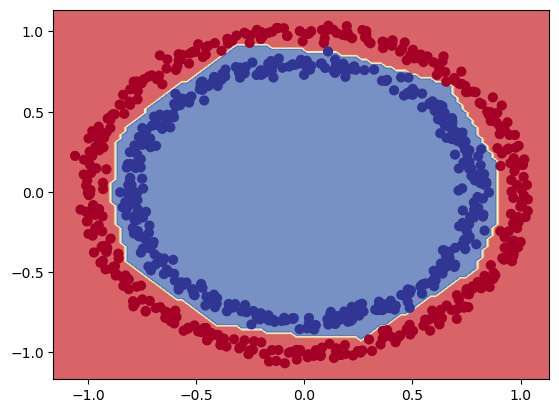

In [60]:
tmp = CircleModelV2()
tmp.load_state_dict(model_3.state_dict())
plot_decision_boundary(tmp, X_train, y_train)

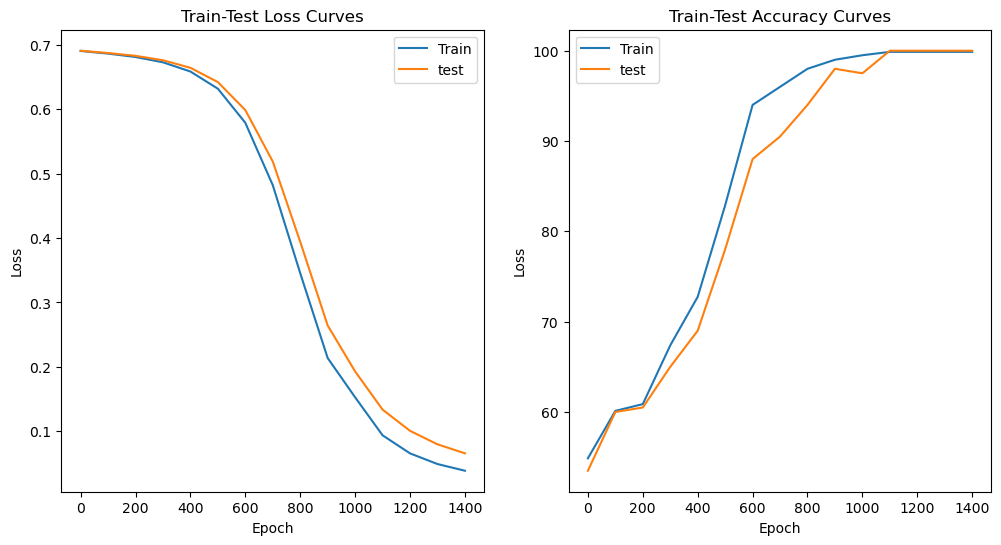

In [61]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epoch_count, train_losses, label="Train")
plt.plot(epoch_count, test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train-Test Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_count, train_accs, label="Train")
plt.plot(epoch_count, test_accs, label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train-Test Accuracy Curves")
plt.legend()
plt.show();

plt.show();

## Fun Experiment :)

In [62]:
model_4 = nn.Sequential(
    nn.Linear(in_features=2, out_features=16),
    nn.Linear(in_features=16, out_features=8),
    nn.Linear(in_features=8, out_features=4),
    nn.Linear(in_features=4, out_features=2),
    nn.Linear(in_features=2, out_features=1),
)
model_4.to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(), lr=0.1)

In [63]:
epochs = 1500

for epoch in range(epochs):
    model_4.train()
    y_logits = model_4(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        # Testing
        model_4.eval()
        with torch.inference_mode():
            y_logits = model_4(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
        test_loss = loss_fn(y_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)
        
        print(f"Epoch: {epoch} | Loss: ({loss.item()}, {test_loss.item()}) | Accuracy: ({acc}, {test_acc})")

Epoch: 0 | Loss: (0.7198212146759033, 0.7201343178749084) | Accuracy: (50.0, 50.0)
Epoch: 100 | Loss: (0.6930252909660339, 0.6943720579147339) | Accuracy: (51.625, 47.5)
Epoch: 200 | Loss: (0.6929888129234314, 0.6943490505218506) | Accuracy: (51.24999999999999, 47.0)
Epoch: 300 | Loss: (0.6929877996444702, 0.6943733096122742) | Accuracy: (51.37500000000001, 46.5)
Epoch: 400 | Loss: (0.6929868459701538, 0.6943965554237366) | Accuracy: (51.24999999999999, 46.5)
Epoch: 500 | Loss: (0.6929860711097717, 0.6944184899330139) | Accuracy: (51.37500000000001, 46.5)
Epoch: 600 | Loss: (0.6929852962493896, 0.6944387555122375) | Accuracy: (51.5, 46.5)
Epoch: 700 | Loss: (0.6929847598075867, 0.6944577097892761) | Accuracy: (51.5, 46.5)
Epoch: 800 | Loss: (0.6929842233657837, 0.6944752335548401) | Accuracy: (51.625, 46.5)
Epoch: 900 | Loss: (0.6929836869239807, 0.6944915652275085) | Accuracy: (51.5, 47.0)
Epoch: 1000 | Loss: (0.6929833292961121, 0.6945065855979919) | Accuracy: (51.37500000000001, 46.

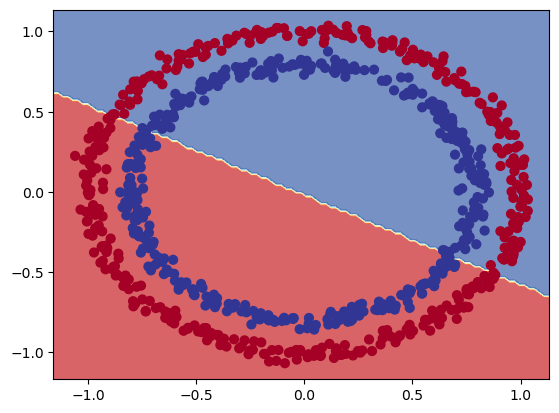

In [64]:
plot_decision_boundary(model_4, X_train, y_train)

In [65]:
model_5 = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=1),
)
model_5.to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_5.parameters(), lr=0.1)

In [66]:
epochs = 15000

for epoch in range(epochs):
    model_5.train()
    y_logits = model_5(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        # Testing
        model_5.eval()
        with torch.inference_mode():
            y_logits = model_5(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
        test_loss = loss_fn(y_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)
        
        print(f"Epoch: {epoch} | Loss: ({loss.item()}, {test_loss.item()}) | Accuracy: ({acc}, {test_acc})")

Epoch: 0 | Loss: (0.693807065486908, 0.6925657987594604) | Accuracy: (50.875, 53.0)
Epoch: 1000 | Loss: (0.5542663931846619, 0.576579749584198) | Accuracy: (89.875, 87.5)
Epoch: 2000 | Loss: (0.04088485985994339, 0.07023100554943085) | Accuracy: (100.0, 99.0)
Epoch: 3000 | Loss: (0.017927581444382668, 0.04125354066491127) | Accuracy: (100.0, 99.0)
Epoch: 4000 | Loss: (0.01165814884006977, 0.03277543932199478) | Accuracy: (100.0, 99.0)
Epoch: 5000 | Loss: (0.008737738244235516, 0.028379343450069427) | Accuracy: (100.0, 99.0)
Epoch: 6000 | Loss: (0.0070464955642819405, 0.025727026164531708) | Accuracy: (100.0, 99.0)
Epoch: 7000 | Loss: (0.0059187160804867744, 0.023800654336810112) | Accuracy: (100.0, 99.0)
Epoch: 8000 | Loss: (0.005108181852847338, 0.022454187273979187) | Accuracy: (100.0, 99.0)
Epoch: 9000 | Loss: (0.004496116656810045, 0.021429026499390602) | Accuracy: (100.0, 99.0)
Epoch: 10000 | Loss: (0.004014812409877777, 0.02060527354478836) | Accuracy: (100.0, 99.0)
Epoch: 11000 

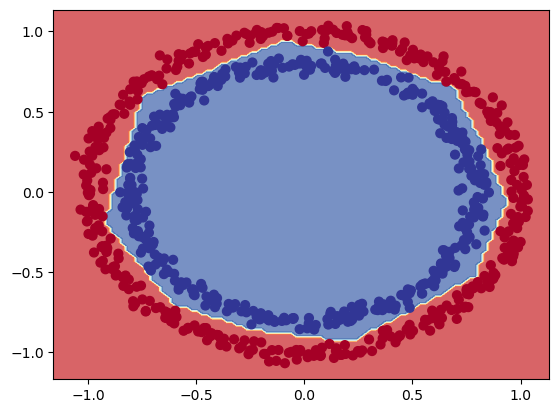

In [67]:
plot_decision_boundary(model_5, X_train, y_train)

## Replicating Non-Linear Activation Functions

In NN we can't tell the model what to learn rather we provide it with tools for discovering the patterns in data on it's own.

These tools include: Linear & Non-Linear Functions 

In [68]:
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

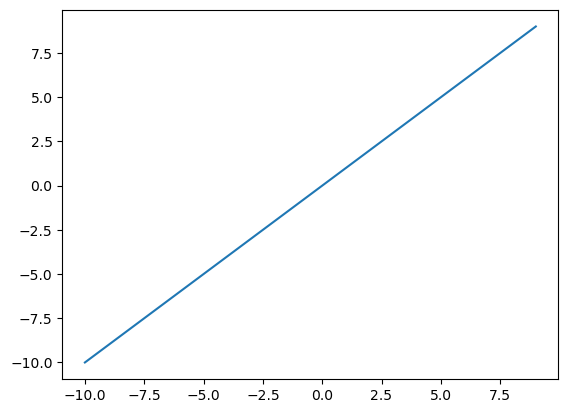

In [69]:
# Visualize
plt.plot(A, A);

In [70]:
torch.relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

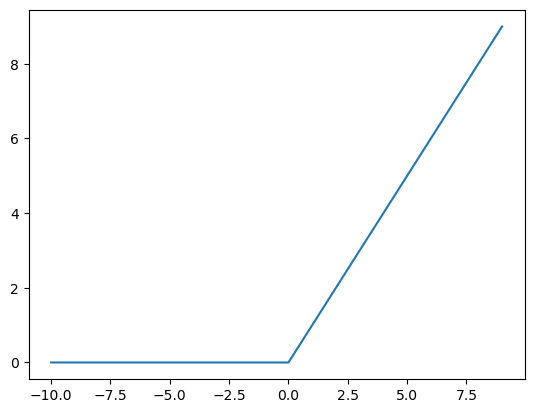

In [71]:
plt.plot(A, torch.relu(A))

In [72]:
def relu(x):
    return torch.max(torch.tensor(0), x)

In [73]:
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

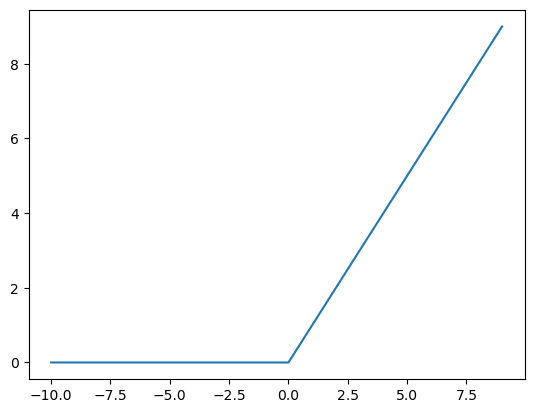

In [74]:
plt.plot(A, relu(A))

In [75]:
torch.sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

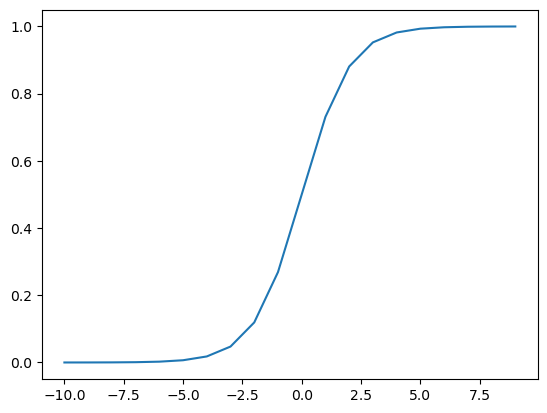

In [76]:
plt.plot(A, torch.sigmoid(A))

In [77]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

In [78]:
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

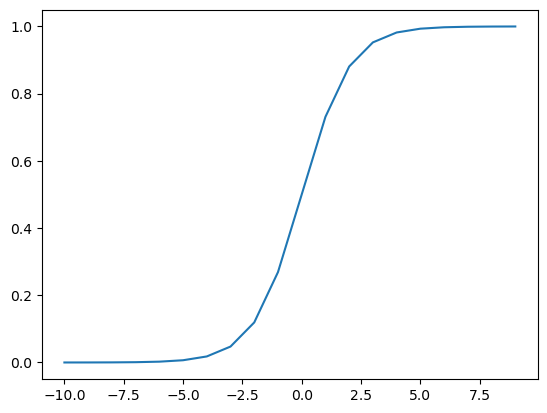

In [79]:
plt.plot(A, sigmoid(A))

In [80]:
def relu6(x):
    return torch.min(torch.tensor(6), torch.max(torch.tensor(0), x))

In [81]:
relu6(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 6.,
        6., 6.])

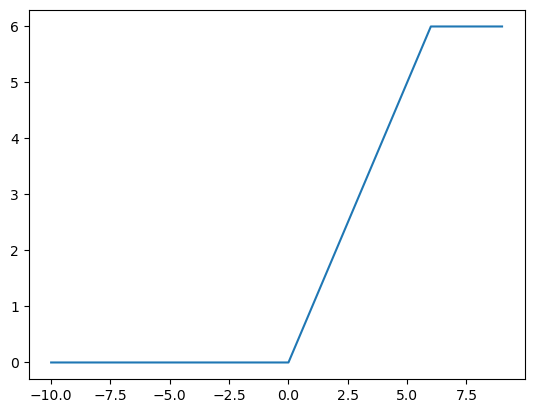

In [82]:
plt.plot(A, relu6(A))

## 8. Multi-Class Classification

### 8.1 Creating a Toy Multi-Class Dataset

In [83]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2

X, y = make_blobs(n_samples=1000, n_features=NUM_FEATURES, centers=NUM_CLASSES, cluster_std=2, random_state=42)

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

len(X_train), X_train[:5], y_train[:5]

(800,
 tensor([[ 5.1740,  3.7524],
         [-2.6634,  9.6966],
         [-9.0722, -9.7602],
         [-5.7417, -3.6233],
         [-3.6165,  6.6185]]),
 tensor([1., 0., 2., 2., 0.]))

In [84]:
X_train.shape, torch.unique(y_train)

(torch.Size([800, 2]), tensor([0., 1., 2., 3.]))

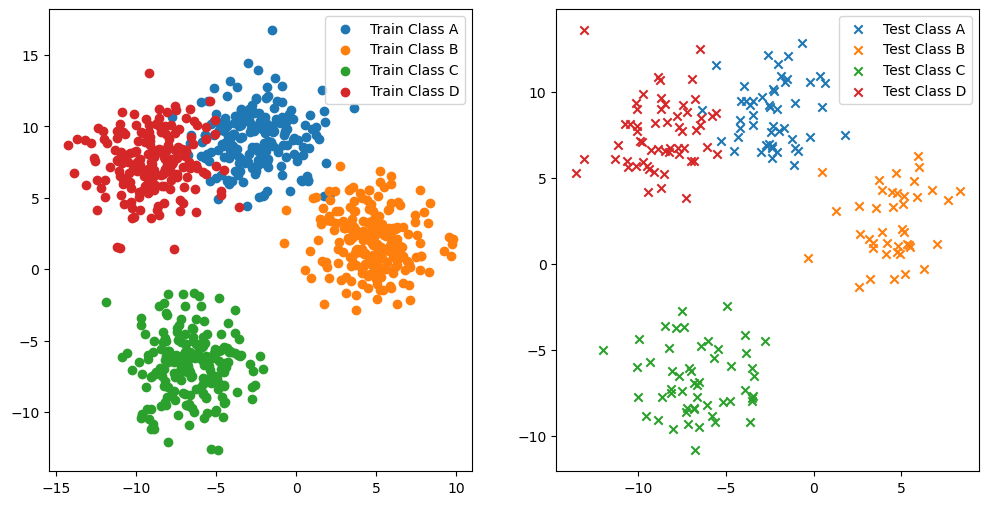

In [85]:
class_names = ["Class A", "Class B", "Class C", "Class D"]

_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))

for i, class_name in enumerate(class_names):
    # Training points
    ax1.scatter(
        X_train[y_train == i, 0],
        X_train[y_train == i, 1],
        label=f"Train {class_name}",
    )

    # Test points
    ax2.scatter(
        X_test[y_test == i, 0],
        X_test[y_test == i, 1],
        marker="x",
        label=f"Test {class_name}",
    )

ax1.legend()
ax2.legend()

plt.show();

### 8.2 Building a mult-class classification

In [86]:
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [87]:
class BlobModel(nn.Module):
    def __init__(self, in_features, out_features, hidden_units=8):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=out_features)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

model_0 = BlobModel(2, 4).to(device)
model_0, model_0.state_dict()

(BlobModel(
   (linear_layer_stack): Sequential(
     (0): Linear(in_features=2, out_features=8, bias=True)
     (1): ReLU()
     (2): Linear(in_features=8, out_features=8, bias=True)
     (3): ReLU()
     (4): Linear(in_features=8, out_features=4, bias=True)
   )
 ),
 OrderedDict([('linear_layer_stack.0.weight',
               tensor([[-0.2118,  0.6827],
                       [ 0.5946, -0.2095],
                       [-0.0743, -0.5359],
                       [-0.2380,  0.1793],
                       [-0.3616, -0.3440],
                       [-0.1497,  0.1634],
                       [-0.4848, -0.5802],
                       [-0.0459,  0.4789]], device='cuda:0')),
              ('linear_layer_stack.0.bias',
               tensor([ 0.1115, -0.4723,  0.6924, -0.4833, -0.5804,  0.0073,  0.7011, -0.2689],
                      device='cuda:0')),
              ('linear_layer_stack.2.weight',
               tensor([[-3.2139e-01, -3.3654e-01, -4.2771e-02, -2.1931e-01, -2.5642e-01,
     

In [88]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

loss_fn, optimizer

(CrossEntropyLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [89]:
model_0.eval()
with torch.inference_mode():
    y_pred = model_0(X_test[:10].to(device)) # Logits/Raw Outputs
y_probs = torch.softmax(y_pred, dim=1) # Output Probabilities
y_label = torch.argmax(y_probs, dim=1) # Output Labels

y_pred, y_probs, y_label, y_test[:10]

(tensor([[-0.5478, -0.0446,  0.2441,  0.0214],
         [-1.6317, -0.1316,  1.3866, -0.5625],
         [-1.0022,  0.0099,  2.2643,  0.0157],
         [-0.1705, -0.0294, -0.2262,  0.0825],
         [-1.6594, -0.1959,  1.4069, -0.6408],
         [-2.0558, -0.1643,  1.8338, -0.7896],
         [-0.9875,  0.0767,  2.1050,  0.0868],
         [-1.5954, -0.1699,  1.3424, -0.5849],
         [-1.2387, -0.1114,  2.8088, -0.1660],
         [-1.5795, -0.1753,  1.3247, -0.5832]], device='cuda:0'),
 tensor([[0.1509, 0.2495, 0.3330, 0.2666],
         [0.0347, 0.1553, 0.7090, 0.1010],
         [0.0305, 0.0840, 0.8009, 0.0845],
         [0.2280, 0.2626, 0.2157, 0.2937],
         [0.0338, 0.1462, 0.7262, 0.0937],
         [0.0166, 0.1104, 0.8139, 0.0591],
         [0.0347, 0.1004, 0.7634, 0.1015],
         [0.0373, 0.1553, 0.7048, 0.1026],
         [0.0156, 0.0480, 0.8909, 0.0455],
         [0.0384, 0.1564, 0.7011, 0.1040]], device='cuda:0'),
 tensor([2, 2, 2, 3, 2, 2, 2, 2, 2, 2], device='cuda:0'),
 ten

In [90]:
epochs = 100

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.type(torch.int64).to(device), y_test.type(torch.int64).to(device)

steps = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []

for e in range(epochs):
    model_0.train()
    y_logits = model_0(X_train)
    y_probs = torch.softmax(y_logits, dim=1)
    y_labels = torch.argmax(y_probs, dim=1)

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if e % 10 == 0:
        model_0.eval()
        with torch.inference_mode():
            y_logits = model_0(X_test)
            y_probs = torch.softmax(y_logits, dim=1)
            y_labels = torch.argmax(y_probs, dim=1)

            test_loss = loss_fn(y_logits, y_test)
            test_acc = accuracy_fn(y_test, y_labels)

            steps.append(e)
            train_losses.append(loss.item())
            test_losses.append(test_loss.item())
            train_accs.append(acc)
            test_accs.append(test_acc)
            
            print(f"Epoch: {e}")
            print(f"\tTrain Loss: {loss} | Test Loss: {test_loss}")
            print(f"\tTrain Accuracy: {acc} | Test Accuracy: {test_acc}")

Epoch: 0
	Train Loss: 1.9001508951187134 | Test Loss: 1.1809207201004028
	Train Accuracy: 36.75 | Test Accuracy: 41.0
Epoch: 10
	Train Loss: 0.8932803273200989 | Test Loss: 0.870108962059021
	Train Accuracy: 70.25 | Test Accuracy: 73.0
Epoch: 20
	Train Loss: 0.7116762399673462 | Test Loss: 0.7135006785392761
	Train Accuracy: 73.625 | Test Accuracy: 74.5
Epoch: 30
	Train Loss: 0.5966583490371704 | Test Loss: 0.6041193008422852
	Train Accuracy: 74.125 | Test Accuracy: 74.5
Epoch: 40
	Train Loss: 0.48843345046043396 | Test Loss: 0.4825502038002014
	Train Accuracy: 74.25 | Test Accuracy: 74.5
Epoch: 50
	Train Loss: 0.3990134000778198 | Test Loss: 0.3853895962238312
	Train Accuracy: 89.75 | Test Accuracy: 94.5
Epoch: 60
	Train Loss: 0.3459380269050598 | Test Loss: 0.3311414420604706
	Train Accuracy: 93.625 | Test Accuracy: 96.0
Epoch: 70
	Train Loss: 0.3093200922012329 | Test Loss: 0.29495519399642944
	Train Accuracy: 95.0 | Test Accuracy: 96.0
Epoch: 80
	Train Loss: 0.28108036518096924 | T

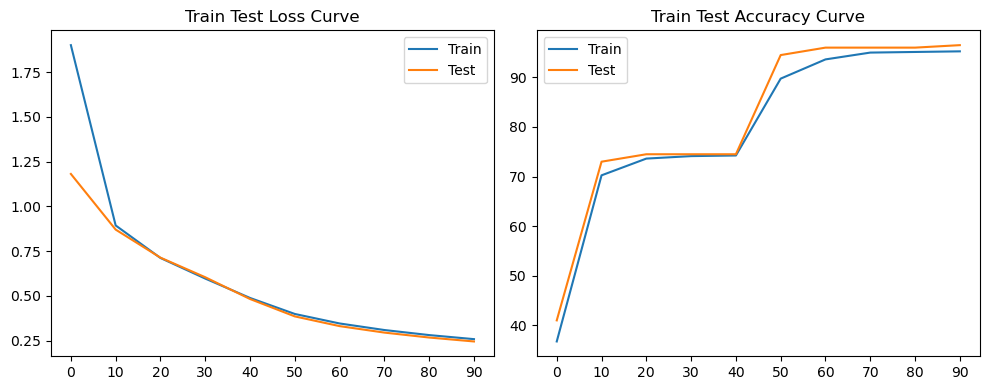

In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(steps, train_losses, label="Train")
ax1.plot(steps, test_losses, label="Test")
ax1.set_title("Train Test Loss Curve")
ax1.set_xticks(steps)
ax1.legend()

ax2.plot(steps, train_accs, label="Train")
ax2.plot(steps, test_accs, label="Test")
ax2.set_title("Train Test Accuracy Curve")
ax2.set_xticks(steps)
ax2.legend()


plt.tight_layout()
plt.show();

In [102]:
model_0.eval()
with torch.inference_mode():
    y_pred = model_0(X_test[:10].to(device)) # Logits/Raw Outputs
y_probs = torch.softmax(y_pred, dim=1) # Output Probabilities
y_label = torch.argmax(y_probs, dim=1) # Output Labels

y_pred, y_probs, y_label, y_test[:10]

(tensor([[-1.3296,  4.1370, -3.3028, -3.4193],
         [-0.1591, -1.5408, -0.7777,  2.8603],
         [-4.6283, -7.0365,  8.4456,  1.4408],
         [-0.8391,  3.1269, -2.7426, -2.6441],
         [ 0.9703, -0.2983, -0.8889, -0.0357],
         [-0.5768, -1.9735, -0.7523,  3.9008],
         [-4.2209, -5.7868,  7.3214,  0.7460],
         [ 0.9718, -0.3086, -0.8821, -0.0260],
         [-5.9368, -9.0809, 10.3803,  2.6694],
         [ 0.9718, -0.3088, -0.8819, -0.0257]], device='cuda:0'),
 tensor([[4.2033e-03, 9.9469e-01, 5.8430e-04, 5.2002e-04],
         [4.4905e-02, 1.1277e-02, 2.4189e-02, 9.1963e-01],
         [2.0974e-06, 1.8872e-07, 9.9909e-01, 9.0671e-04],
         [1.8489e-02, 9.7571e-01, 2.7558e-03, 3.0411e-03],
         [5.5472e-01, 1.5601e-01, 8.6420e-02, 2.0286e-01],
         [1.1098e-02, 2.7455e-03, 9.3107e-03, 9.7685e-01],
         [9.6970e-06, 2.0257e-06, 9.9860e-01, 1.3923e-03],
         [5.5455e-01, 1.5413e-01, 8.6857e-02, 2.0447e-01],
         [8.1916e-08, 3.5311e-09, 9.995

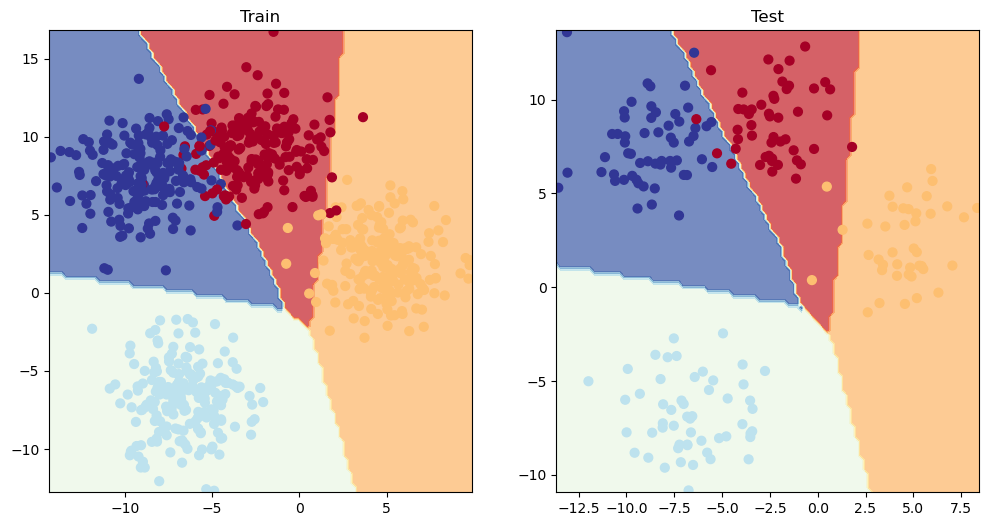

In [93]:
tmp = BlobModel(2, 4)
tmp.load_state_dict(model_0.state_dict())


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(tmp, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(tmp, X_test, y_test)

### 8.1 Trying with Linear Model Only

In [94]:
model_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=8),
    nn.Linear(in_features=8, out_features=8),
    nn.Linear(in_features=8, out_features=4),
)
model_1.to(device)
model_1, model_1.state_dict()

(Sequential(
   (0): Linear(in_features=2, out_features=8, bias=True)
   (1): Linear(in_features=8, out_features=8, bias=True)
   (2): Linear(in_features=8, out_features=4, bias=True)
 ),
 OrderedDict([('0.weight',
               tensor([[ 0.1192,  0.6795],
                       [ 0.2694,  0.2693],
                       [-0.0568, -0.6804],
                       [-0.2062, -0.4439],
                       [-0.4859,  0.0716],
                       [-0.1445, -0.0734],
                       [ 0.2587, -0.0609],
                       [-0.2815, -0.1501]], device='cuda:0')),
              ('0.bias',
               tensor([ 0.5365,  0.2747, -0.0898,  0.0058,  0.1972, -0.1809, -0.4709, -0.0736],
                      device='cuda:0')),
              ('1.weight',
               tensor([[-3.0058e-01,  6.7156e-02, -6.2963e-02,  3.7014e-05, -2.9761e-01,
                         9.9891e-03,  1.9225e-01, -2.8585e-01],
                       [ 1.8585e-01, -3.2468e-01,  7.1459e-02,  3.3535e-01, -2.

In [95]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

loss_fn, optimizer

(CrossEntropyLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [96]:
epochs = 100

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.type(torch.int64).to(device), y_test.type(torch.int64).to(device)

steps = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []

for e in range(epochs):
    model_1.train()
    y_logits = model_1(X_train)
    y_probs = torch.softmax(y_logits, dim=1)
    y_labels = torch.argmax(y_probs, dim=1)

    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_train, y_labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if e % 10 == 0:
        model_1.eval()
        with torch.inference_mode():
            y_logits = model_1(X_test)
            y_probs = torch.softmax(y_logits, dim=1)
            y_labels = torch.argmax(y_probs, dim=1)

            test_loss = loss_fn(y_logits, y_test)
            test_acc = accuracy_fn(y_test, y_labels)

            steps.append(e)
            train_losses.append(loss.item())
            test_losses.append(test_loss.item())
            train_accs.append(acc)
            test_accs.append(test_acc)
            
            print(f"Epoch: {e}")
            print(f"\tTrain Loss: {loss} | Test Loss: {test_loss}")
            print(f"\tTrain Accuracy: {acc} | Test Accuracy: {test_acc}")

Epoch: 0
	Train Loss: 1.6388869285583496 | Test Loss: 0.9278671741485596
	Train Accuracy: 0.0 | Test Accuracy: 55.50000000000001
Epoch: 10
	Train Loss: 0.3231380879878998 | Test Loss: 0.29225796461105347
	Train Accuracy: 95.5 | Test Accuracy: 96.5
Epoch: 20
	Train Loss: 0.17566272616386414 | Test Loss: 0.16198484599590302
	Train Accuracy: 95.75 | Test Accuracy: 96.5
Epoch: 30
	Train Loss: 0.13511385023593903 | Test Loss: 0.1222025603055954
	Train Accuracy: 95.875 | Test Accuracy: 96.5
Epoch: 40
	Train Loss: 0.11838449537754059 | Test Loss: 0.1049237921833992
	Train Accuracy: 96.0 | Test Accuracy: 96.5
Epoch: 50
	Train Loss: 0.1098691076040268 | Test Loss: 0.09587406367063522
	Train Accuracy: 96.0 | Test Accuracy: 96.5
Epoch: 60
	Train Loss: 0.10492557287216187 | Test Loss: 0.09054246544837952
	Train Accuracy: 96.0 | Test Accuracy: 96.5
Epoch: 70
	Train Loss: 0.10177776217460632 | Test Loss: 0.08713173866271973
	Train Accuracy: 96.0 | Test Accuracy: 96.5
Epoch: 80
	Train Loss: 0.0996271

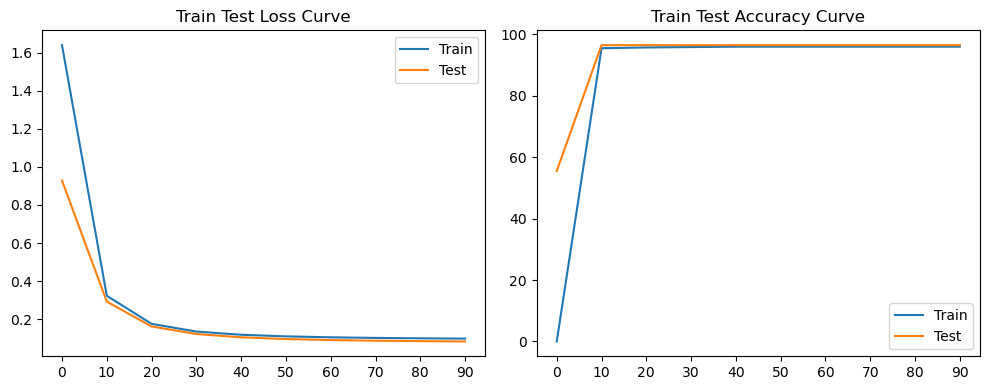

In [97]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(steps, train_losses, label="Train")
ax1.plot(steps, test_losses, label="Test")
ax1.set_title("Train Test Loss Curve")
ax1.set_xticks(steps)
ax1.legend()

ax2.plot(steps, train_accs, label="Train")
ax2.plot(steps, test_accs, label="Test")
ax2.set_title("Train Test Accuracy Curve")
ax2.set_xticks(steps)
ax2.legend()


plt.tight_layout()
plt.show();

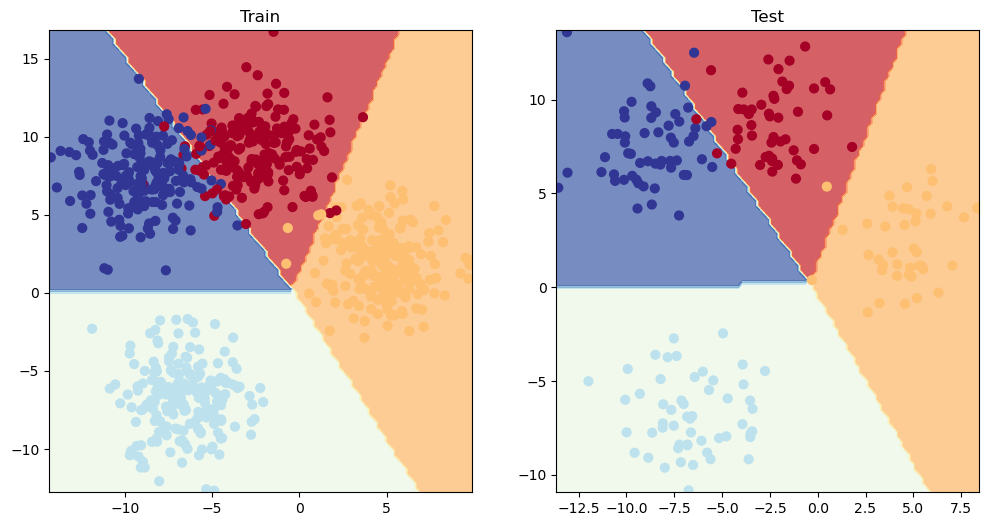

In [98]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

## 9. A few more classification metrics

- Accuracy: Out of all predictions, how many does your model get correct?
    - $ \frac{tp + tn}{tp + tn + fp + fn} $
    - `torchmetrics.Accuracy()`, `sklearn.metrics.accuracy_score()`
    - Default metric for classification but not great for imbalanced data.
- Precision: Propotion of true positive over total number of samples. Out of all predicted positives, how many were actually positive?
    - $ \frac{tp}{tp + fp} $
    - `torchmetrics.Precision()`, `sklearn.metrics.precision_score()`
    - Higher precision leads to less false positives.
- Recall: Propotion of true positive over total number of true positives and false negatives. Out of all actual positives, how many did the model catch?
    - $ \frac{tp}{tp + fn} $
    - `torchmetrics.Recall()`, `sklearn.metrics.recall_score()`
    - Higher recall leads to less false negatives.
- F1-Score: Combines precision and recall into one metric. 1 means best, 0 means worst score
    - $ 2 \times \frac{Precision \times Recall}{Precision + Recall} $
- Confusion Matrix: compares the predicted values with the true values in a tabular way, if 100% correct, all values in matrix will be top left to bottom right (diagonal line).
- Classification Report: collection of some of the main classification metrics such as precision, recall & F1-Score.

In [116]:
from torchmetrics.classification import Accuracy

acc = Accuracy(task="multiclass", num_classes=4).to(device)

y_logits = model_0(X_test)
y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

print(f"Model-0: {acc(y_preds, y_test):.4f}")


y_logits = model_1.to(device)(X_test)
y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

print(f"Model-1: {acc(y_preds, y_test):.4f}")

Model-0: 0.9650
Model-1: 0.9650
